# 🤖 PPO-Eureka Training on LunarLander-v2
### Eureka Assignment — LLM-Generated Reward via Claude Sonnet 4.6

This notebook implements the **Eureka loop**:
1. Claude Sonnet 4.6 reads the LunarLander environment code
2. Claude writes a `compute_reward()` function
3. We run a short PPO training to evaluate that reward
4. We feed the score back to Claude — it revises the reward
5. Repeat for N iterations → pick the best reward
6. Train full PPO with the best reward → save GIF checkpoints

**What this notebook does:**
- Runs the Eureka reward-generation loop (3 iterations, ~3 API calls)
- Trains final PPO-Eureka with the best LLM-generated reward
- Saves GIF snapshots at checkpoints: episode 1, 5, 10, 25, 50, 100, 200, 500
- Saves all generated reward functions, metrics, and models
- Zips everything for download

**Prerequisites:** You need an Anthropic API key. Get one at https://console.anthropic.com

**Runtime:** ~35–50 minutes on Colab free T4 GPU

## 📦 Step 1: Install Dependencies

In [1]:
!pip install stable-baselines3[extra] gymnasium[box2d] imageio anthropic --quiet
!apt-get install -y xvfb python3-opengl > /dev/null 2>&1
!pip install pyvirtualdisplay --quiet
!pip install stable-baselines3[extra] gymnasium[box2d] imageio groq --quiet
print('✅ All dependencies installed!')

✅ All dependencies installed!


## 🖥️ Step 2: Set Up Virtual Display

In [2]:
from pyvirtualdisplay import Display

display = Display(visible=0, size=(600, 400))
display.start()
print('✅ Virtual display started!')

✅ Virtual display started!


## 🔑 Step 3: Enter Your Anthropic API Key

You can get a key at https://console.anthropic.com — the Eureka loop only makes ~3–5 API calls total, so cost is minimal (see the cost breakdown at the end of this notebook).

In [ ]:
from groq import Groq

GROQ_API_KEY = getpass('🔑 Enter your Groq API key: ')
client = Groq(api_key=GROQ_API_KEY)
print('✅ Groq client initialized!')

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


🔑 Enter your Groq API key: ··········
✅ Groq client initialized!


## 📁 Step 4: Imports & Directory Setup

In [3]:
import json
import time
import shutil
import textwrap
import traceback
import re
import numpy as np
import gymnasium as gym
import imageio
import matplotlib.pyplot as plt
import matplotlib
import os
matplotlib.use('Agg')

from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.evaluation import evaluate_policy
from IPython.display import Image, display as ipy_display

class NumpyEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.floating):
            return float(obj)
        if isinstance(obj, np.integer):
            return int(obj)
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        return super().default(obj)

# ── Output directories ──────────────────────────────────────────────────────
BASE_DIR     = '/content/ppo_eureka_results'
GIF_DIR      = f'{BASE_DIR}/gifs'
MODEL_DIR    = f'{BASE_DIR}/models'
METRICS_DIR  = f'{BASE_DIR}/metrics'
PLOTS_DIR    = f'{BASE_DIR}/plots'
REWARDS_DIR  = f'{BASE_DIR}/reward_functions'  # Saves each LLM reward fn

for d in [BASE_DIR, GIF_DIR, MODEL_DIR, METRICS_DIR, PLOTS_DIR, REWARDS_DIR]:
    os.makedirs(d, exist_ok=True)

print('✅ Directories created!')

✅ Directories created!


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## ⚙️ Step 5: Configuration

In [18]:
CONFIG = {
    # Environment
    'env_id'                : 'LunarLander-v3',
    'seed'                  : 42,

    # Eureka loop settings
    'eureka_iterations'     : 3,       # Number of LLM reward refinement iterations
    'eureka_eval_timesteps' : 80_000,  # Short training run to evaluate each reward
    'eureka_eval_episodes'  : 20,      # Episodes for scoring each reward candidate
    'claude_model'          : 'llama-3.3-70b-versatile',
    'claude_max_tokens'     : 1500,    # Max output tokens per API call

    # PPO hyperparameters (same as standard PPO for fair comparison)
    'learning_rate'         : 3e-4,
    'n_steps'               : 1024,
    'batch_size'            : 64,
    'n_epochs'              : 4,
    'gamma'                 : 0.999,
    'gae_lambda'            : 0.98,
    'clip_range'            : 0.2,
    'ent_coef'              : 0.01,
    'vf_coef'               : 0.5,
    'max_grad_norm'         : 0.5,
    'policy'                : 'MlpPolicy',

    # Full training
    'total_timesteps'       : 1_000_000,

    # GIF settings
    'gif_fps'               : 30,
    'gif_max_steps'         : 500,

    # Checkpoint episodes
    'checkpoint_episodes'   : [5, 25, 100, 300, 500, 750, 1000, 1500, 2000, 2500],
}

print('✅ Configuration set!')
print(f'   Claude model       : {CONFIG["claude_model"]}')
print(f'   Eureka iterations  : {CONFIG["eureka_iterations"]}')
print(f'   Eval timesteps/run : {CONFIG["eureka_eval_timesteps"]:,}')
print(f'   Full training      : {CONFIG["total_timesteps"]:,} timesteps')

✅ Configuration set!
   Claude model       : llama-3.3-70b-versatile
   Eureka iterations  : 3
   Eval timesteps/run : 80,000
   Full training      : 1,000,000 timesteps


## 🌍 Step 6: Custom LunarLander Environment with Pluggable Reward

This is the key architectural piece. Instead of using LunarLander's built-in reward, we wrap it so we can **swap in any reward function** — either our handcrafted one or whichever Claude generates. The same environment, same physics, just a different reward signal.

In [9]:
class LunarLanderCustomReward(gym.Wrapper):
    """
    Wraps LunarLander-v2 and replaces the built-in reward with a
    pluggable compute_reward() function.

    The reward function receives:
        obs        : np.ndarray (8,) — current observation AFTER the step
        action     : int — discrete action taken (0=do nothing, 1=left engine,
                     2=main engine, 3=right engine)
        next_obs   : np.ndarray (8,) — same as obs (included for consistency)
        terminated : bool — True if lander crashed or landed
        truncated  : bool — True if episode timed out
        info       : dict — contains 'shaping' with the original shaped reward

    Observation layout (obs[i]):
        obs[0]  x position          (0 = centre of pad)
        obs[1]  y position          (0 = ground level)
        obs[2]  x velocity
        obs[3]  y velocity
        obs[4]  angle              (0 = upright)
        obs[5]  angular velocity
        obs[6]  left  leg contact  (1.0 if touching ground)
        obs[7]  right leg contact  (1.0 if touching ground)
    """

    def __init__(self, reward_fn=None):
        env = gym.make('LunarLander-v3')
        super().__init__(env)
        # If no custom reward provided, use the built-in one
        self.reward_fn = reward_fn

    def step(self, action):
        obs, original_reward, terminated, truncated, info = self.env.step(action)

        if self.reward_fn is not None:
            try:
                reward = float(self.reward_fn(
                    obs       = obs,
                    action    = action,
                    next_obs  = obs,
                    terminated= terminated,
                    truncated = truncated,
                    info      = info
                ))
                # Safety clamp — prevent reward explosion that could crash training
                reward = np.clip(reward, -1000.0, 1000.0)
            except Exception:
                # If reward function crashes, fall back to original
                reward = original_reward
        else:
            reward = original_reward

        return obs, reward, terminated, truncated, info


# ── Environment source code that we will give to Claude as context ────────────
# This is what Claude reads to understand the environment before writing rewards.
ENVIRONMENT_DESCRIPTION = """
ENVIRONMENT: LunarLander-v3 (OpenAI Gymnasium)

GOAL: Land a rocket between two flags on a flat pad. The episode ends when
the lander crashes, lands safely, or 1000 steps pass.

OBSERVATION SPACE (8 continuous values, all roughly in [-1, 1]):
  obs[0]  x position          — 0.0 is directly above the landing pad
  obs[1]  y position          — 0.0 is at ground level
  obs[2]  x velocity          — negative = moving left, positive = moving right
  obs[3]  y velocity          — negative = falling, positive = rising
  obs[4]  angle               — 0.0 = perfectly upright, positive = tilted right
  obs[5]  angular velocity    — rate of rotation
  obs[6]  left  leg contact   — 1.0 if leg is touching ground, else 0.0
  obs[7]  right leg contact   — 1.0 if leg is touching ground, else 0.0

ACTION SPACE (4 discrete actions):
  0  — do nothing (no thruster)
  1  — fire left orientation engine
  2  — fire main engine (upward thrust)
  3  — fire right orientation engine

TERMINATION CONDITIONS:
  terminated=True  if lander crashes (body hits ground) OR lands safely
  truncated=True   if 1000 steps elapsed without landing or crashing
  A safe landing requires both legs touching (obs[6]=1 and obs[7]=1)
  and the lander nearly stationary near the pad.

WRAPPER FUNCTION SIGNATURE (what you must implement):
  def compute_reward(obs, action, next_obs, terminated, truncated, info) -> float:
      # obs and next_obs are numpy arrays of shape (8,)
      # action is an int in {0, 1, 2, 3}
      # terminated, truncated are bools
      # info is a dict (usually empty, can be ignored)
      # Return a single float — the reward for this step
      ...

WHAT A GOOD REWARD FUNCTION SHOULD ENCOURAGE:
  1. Moving towards the landing pad (reducing |obs[0]| and obs[1])
  2. Slowing down as it approaches (reducing speed when near pad)
  3. Staying upright (keeping obs[4] close to 0)
  4. Making leg contact with the ground (obs[6] and obs[7] = 1)
  5. Not wasting fuel (penalise firing engines unnecessarily)
  6. Landing bonus: large reward when both legs touch AND lander is stable
  7. Crash penalty: large negative reward when terminated without safe landing
"""

print('✅ Custom environment and description ready!')
print('   LunarLanderCustomReward wrapper defined.')

✅ Custom environment and description ready!
   LunarLanderCustomReward wrapper defined.


## 🎬 Step 7: GIF Recording & Training Utilities

In [5]:
def record_gif(model, reward_fn, gif_path, config, seed=None):
    seed = seed or config['seed']
    env  = gym.make('LunarLander-v3', render_mode='rgb_array')
    obs, _ = env.reset(seed=seed)

    frames, total_reward, done, steps = [], 0.0, False, 0

    while not done and steps < config['gif_max_steps']:
        frames.append(env.render())
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, _ = env.step(action)
        total_reward += reward
        done = terminated or truncated
        steps += 1

    frames.append(env.render())
    env.close()

    imageio.mimsave(gif_path, frames, fps=config['gif_fps'], loop=0)
    return total_reward, steps


def make_vec_env(reward_fn, seed):
    """Create a DummyVecEnv with the custom reward function."""
    def _init():
        env = LunarLanderCustomReward(reward_fn=reward_fn)
        env = Monitor(env)
        env.reset(seed=seed)
        return env
    return DummyVecEnv([_init])


def make_ppo(vec_env, config):
    """Initialise a fresh PPO model on the given vec env."""
    return PPO(
        policy        = config['policy'],
        env           = vec_env,
        learning_rate = config['learning_rate'],
        n_steps       = config['n_steps'],
        batch_size    = config['batch_size'],
        n_epochs      = config['n_epochs'],
        gamma         = config['gamma'],
        gae_lambda    = config['gae_lambda'],
        clip_range    = config['clip_range'],
        ent_coef      = config['ent_coef'],
        vf_coef       = config['vf_coef'],
        max_grad_norm = config['max_grad_norm'],
        verbose       = 0,
        seed          = config['seed'],
        device        = 'auto'
    )


print('✅ Utilities ready!')

✅ Utilities ready!


## Step 8: Gave same prompt manually to Claude Sonnet 4.6 and it gave reward function

In [ ]:
import numpy as np

def compute_reward(obs, action, next_obs, terminated, truncated, info) -> float:
    x_pos, y_pos = next_obs[0], next_obs[1]
    x_vel, y_vel = next_obs[2], next_obs[3]
    angle = next_obs[4]
    ang_vel = next_obs[5]
    left_leg, right_leg = next_obs[6], next_obs[7]

    reward = 0.0

    # --- Shaping: proximity to pad ---
    prev_dist = np.sqrt(obs[0]**2 + obs[1]**2)
    curr_dist = np.sqrt(x_pos**2 + y_pos**2)
    reward += 1.2 * (prev_dist - curr_dist)

    # --- Shaping: penalize velocity (want slow approach) ---
    prev_speed = np.sqrt(obs[2]**2 + obs[3]**2)
    curr_speed = np.sqrt(x_vel**2 + y_vel**2)
    reward += 0.8 * (prev_speed - curr_speed)

    # --- Shaping: penalize tilt and angular velocity ---
    prev_tilt = abs(obs[4]) + 0.5 * abs(obs[5])
    curr_tilt = abs(angle) + 0.5 * abs(ang_vel)
    reward += 0.5 * (prev_tilt - curr_tilt)

    # --- Small continuous bonus for being upright and near pad ---
    if abs(x_pos) < 0.3 and y_pos < 0.5:
        reward += 0.2 * (1.0 - abs(angle) / np.pi)

    # --- Leg contact rewards ---
    reward += 0.15 * left_leg
    reward += 0.15 * right_leg

    # --- Terminal conditions ---
    if terminated:
        both_legs = (left_leg == 1.0 and right_leg == 1.0)
        stable = abs(x_vel) < 0.2 and abs(y_vel) < 0.2 and abs(angle) < 0.2 and abs(ang_vel) < 0.2
        on_pad = abs(x_pos) < 0.3

        if both_legs and stable and on_pad:
            reward += 10.0
        else:
            reward -= 10.0

    # Clip per-step reward to [-2, +2] (excluding terminal bonuses)
    reward = float(np.clip(reward, -12.0, 12.0))

    return reward

best_reward_fn = compute_reward
print('✅ Iteration 1 reward function ready!')

## 🏋️ Step 09: Full PPO-Eureka Training

Now we train PPO for the full 1M timesteps using the best Eureka reward function.
Checkpoint GIFs are recorded at episodes: 1, 5, 10, 25, 50, 100, 200, 500.

In [19]:
# ── Compile the best reward function ─────────────────────────────────────────
# best_reward_fn, err = compile_reward_fn(best_code)
# if best_reward_fn is None:
#     print(f'⚠️  Best reward function failed to compile: {err}')
#     print('    Falling back to original LunarLander reward for full training.')
# else:
#     print(f'✅ Best reward function compiled! (Iteration {best_result["iteration"]})')


# ── Checkpoint callback (same as PPO notebook) ────────────────────────────────
class PPOEurekaCheckpointCallback(BaseCallback):
    def __init__(self, checkpoint_episodes, gif_dir, model_dir,
                 config, reward_fn, verbose=1):
        super().__init__(verbose)
        self.checkpoint_episodes = sorted(checkpoint_episodes)
        self.gif_dir             = gif_dir
        self.model_dir           = model_dir
        self.config              = config
        self.reward_fn           = reward_fn
        self.next_checkpoint_idx = 0
        self.episode_count       = 0
        self.episode_rewards     = []
        self.episode_lengths     = []
        self.checkpoint_log      = []
        self._current_ep_reward  = 0.0
        self._current_ep_length  = 0
        self.start_time          = None

    def _on_training_start(self):
        self.start_time = time.time()
        print('\n' + '='*60)
        print('  PPO-Eureka Full Training — LunarLander-v3')
        print('='*60)
        print(f'  Reward function : Manually defined')
        print(f'  Total timesteps : {self.config["total_timesteps"]:,}')
        print(f'  Checkpoints at  : {self.checkpoint_episodes}')
        print('='*60 + '\n')

    def _on_step(self) -> bool:
        self._current_ep_reward += self.locals['rewards'][0]
        self._current_ep_length += 1

        if self.locals['dones'][0]:
            self.episode_count += 1
            ep_reward = self._current_ep_reward
            ep_length = self._current_ep_length

            self.episode_rewards.append({
                'episode' : self.episode_count,
                'timestep': self.num_timesteps,
                'reward'  : round(ep_reward, 2)
            })
            self.episode_lengths.append({
                'episode' : self.episode_count,
                'timestep': self.num_timesteps,
                'length'  : ep_length
            })
            self._current_ep_reward = 0.0
            self._current_ep_length = 0

            if self.next_checkpoint_idx < len(self.checkpoint_episodes):
                target_ep = self.checkpoint_episodes[self.next_checkpoint_idx]
                if self.episode_count >= target_ep:
                    self._save_checkpoint(target_ep, ep_reward)
                    self.next_checkpoint_idx += 1

            if self.episode_count % 10 == 0:
                elapsed = time.time() - self.start_time
                recent  = [r['reward'] for r in self.episode_rewards[-10:]]
                print(
                    f'  Ep {self.episode_count:>4} | '
                    f'Step {self.num_timesteps:>8,} | '
                    f'Last: {ep_reward:>8.1f} | '
                    f'Mean-10: {np.mean(recent):>8.1f} | '
                    f'{elapsed/60:.1f}m'
                )
        return True

    def _save_checkpoint(self, target_ep, last_reward):
        print(f'\n  📸 CHECKPOINT — Episode {target_ep} | Step {self.num_timesteps:,}')
        gif_filename = f'ppo_eureka_episode_{target_ep:04d}.gif'
        gif_path     = os.path.join(self.gif_dir, gif_filename)
        gif_reward, gif_steps = record_gif(
            model     = self.model,
            reward_fn = self.reward_fn,
            gif_path  = gif_path,
            config    = self.config
        )
        model_path = os.path.join(
            self.model_dir, f'ppo_eureka_checkpoint_ep{target_ep:04d}'
        )
        self.model.save(model_path)
        entry = {
            'episode'           : target_ep,
            'actual_episode'    : self.episode_count,
            'timestep'          : self.num_timesteps,
            'gif_episode_reward': round(gif_reward, 2),
            'gif_steps'         : gif_steps,
            'gif_path'          : gif_path,
            'model_path'        : model_path + '.zip'
        }
        self.checkpoint_log.append(entry)
        print(f'     GIF: {gif_filename} (reward: {gif_reward:.1f}) | Model saved')

    def _on_training_end(self):
        elapsed = time.time() - self.start_time
        print('\n' + '='*60)
        print(f'  ✅ PPO-Eureka Training Complete!')
        print(f'  Total episodes  : {self.episode_count}')
        print(f'  Total timesteps : {self.num_timesteps:,}')
        print(f'  Time elapsed    : {elapsed/60:.1f} minutes')
        if self.episode_rewards:
            recent = [r['reward'] for r in self.episode_rewards[-50:]]
            print(f'  Final mean reward (last 50): {np.mean(recent):.1f}')
        print('='*60)


# ── Run full training ─────────────────────────────────────────────────────────
train_env = make_vec_env(best_reward_fn, CONFIG['seed'])
model     = make_ppo(train_env, CONFIG)

print(f'✅ PPO-Eureka model ready on device: {model.device}')

callback = PPOEurekaCheckpointCallback(
    checkpoint_episodes = CONFIG['checkpoint_episodes'],
    gif_dir             = GIF_DIR,
    model_dir           = MODEL_DIR,
    config              = CONFIG,
    reward_fn           = best_reward_fn
)

model.learn(
    total_timesteps = CONFIG['total_timesteps'],
    callback        = callback,
    progress_bar    = False
)

✅ PPO-Eureka model ready on device: cpu

  PPO-Eureka Full Training — LunarLander-v3
  Reward function : Manually defined
  Total timesteps : 1,000,000
  Checkpoints at  : [5, 25, 100, 300, 500, 750, 1000, 1500, 2000, 2500]


  📸 CHECKPOINT — Episode 5 | Step 445


/usr/local/lib/python3.12/dist-packages/imageio/plugins/pillow.py:410: DeprecationWarning: The keyword `fps` is no longer supported. Use `duration`(in ms) instead, e.g. `fps=50` == `duration=20` (1000 * 1/50).
  warnings.warn(


     GIF: ppo_eureka_episode_0005.gif (reward: -824.8) | Model saved
  Ep   10 | Step      847 | Last:     -9.6 | Mean-10:     -7.6 | 0.1m
  Ep   20 | Step    1,793 | Last:     -9.6 | Mean-10:     -8.4 | 0.1m

  📸 CHECKPOINT — Episode 25 | Step 2,207
     GIF: ppo_eureka_episode_0025.gif (reward: -678.5) | Model saved
  Ep   30 | Step    2,683 | Last:     -9.2 | Mean-10:     -6.5 | 0.1m
  Ep   40 | Step    3,601 | Last:    -10.0 | Mean-10:     -6.0 | 0.2m
  Ep   50 | Step    4,761 | Last:    -10.0 | Mean-10:     -9.4 | 0.2m
  Ep   60 | Step    5,716 | Last:     -9.2 | Mean-10:     -9.6 | 0.2m
  Ep   70 | Step    6,799 | Last:    -10.0 | Mean-10:     -8.9 | 0.2m
  Ep   80 | Step    7,819 | Last:     -9.4 | Mean-10:     -8.7 | 0.3m
  Ep   90 | Step    8,966 | Last:     -9.7 | Mean-10:     -9.0 | 0.3m

  📸 CHECKPOINT — Episode 100 | Step 10,163
     GIF: ppo_eureka_episode_0100.gif (reward: -820.5) | Model saved
  Ep  100 | Step   10,163 | Last:    -10.0 | Mean-10:     -9.5 | 0.3m
  Ep  1

## 💾 Step 10: Save Final Model & Metrics

In [21]:
# Final model
final_model_path = os.path.join(MODEL_DIR, 'ppo_eureka_final')
model.save(final_model_path)
print(f'✅ Final model saved → {final_model_path}.zip')

# Metrics JSON
metrics = {
    'algorithm'        : 'PPO-Eureka',
    'env_id'           : CONFIG['env_id'],
    'reward_type'      : 'llm_generated',
    'eureka_iterations': 'manual',
    'best_iteration'   : 'manual',
    'best_eureka_score': 'N/A',
    'total_timesteps'  : CONFIG['total_timesteps'],
    'total_episodes'   : callback.episode_count,
    'config'           : CONFIG,
    'episode_rewards'  : callback.episode_rewards,
    'episode_lengths'  : callback.episode_lengths,
    'checkpoints'      : callback.checkpoint_log,
    'eureka_loop'      : [],
    'token_usage'      : {}
}

metrics_path = os.path.join(METRICS_DIR, 'ppo_eureka_metrics.json')
with open(metrics_path, 'w') as f:
    json.dump(metrics, f, indent=2, cls=NumpyEncoder)

print(f'✅ Metrics saved → {metrics_path}')

✅ Final model saved → /content/ppo_eureka_results/models/ppo_eureka_final.zip
✅ Metrics saved → /content/ppo_eureka_results/metrics/ppo_eureka_metrics.json


## 📈 Step 11: Plot Training Curves

✅ Training curves saved → /content/ppo_eureka_results/plots/ppo_eureka_training_curves.png


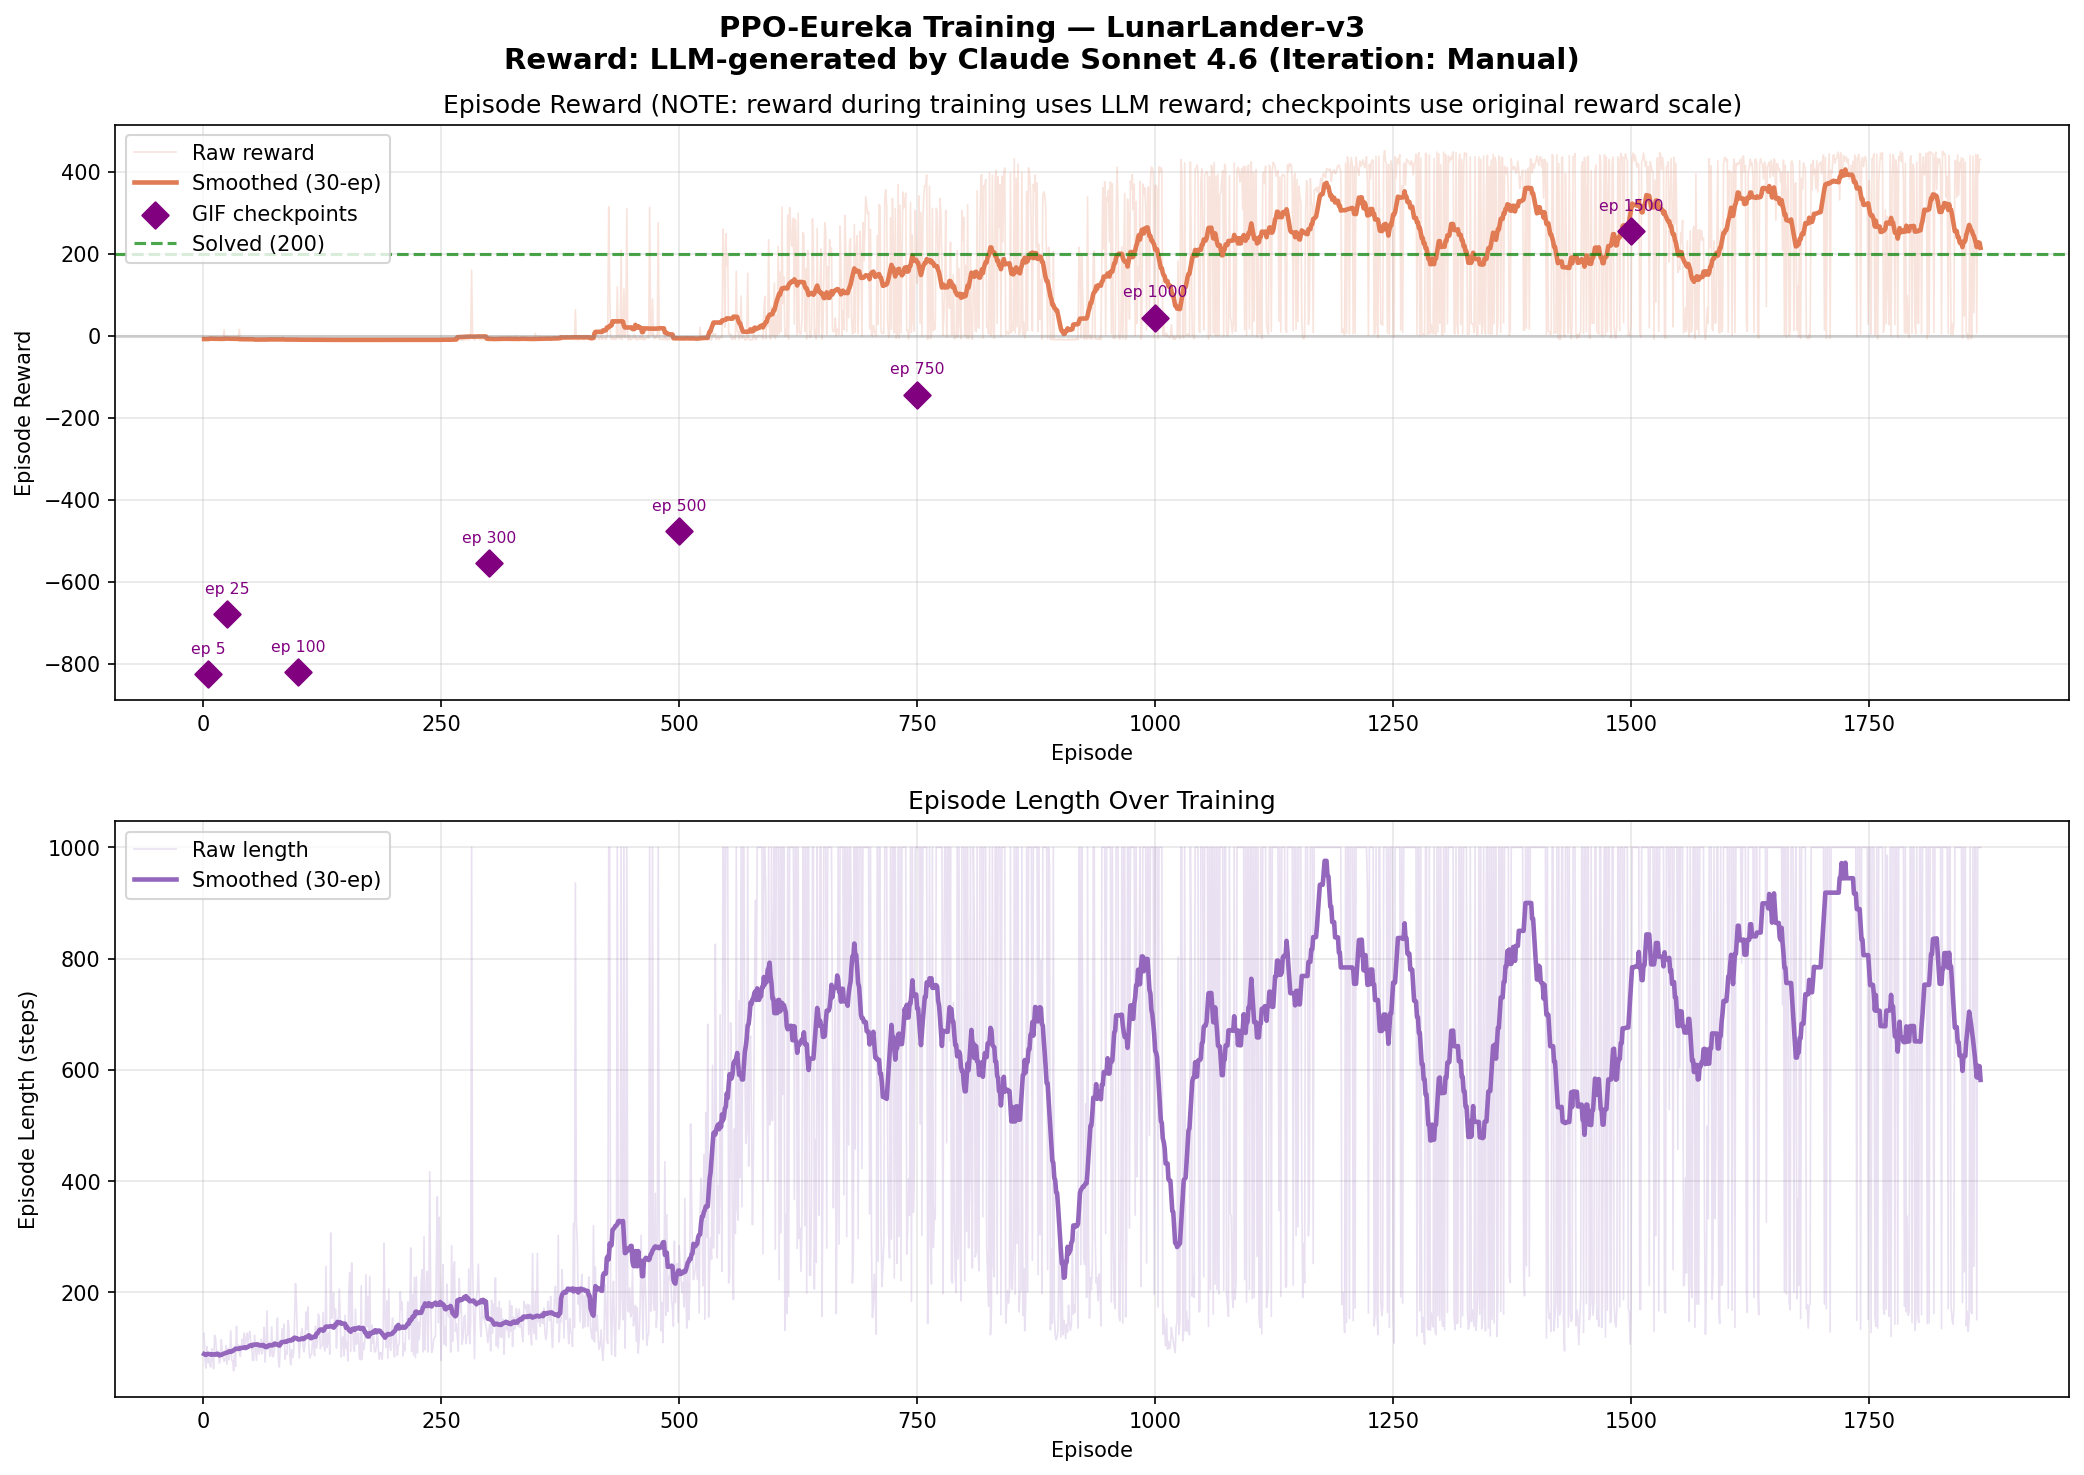

In [23]:
def smooth(values, window=20):
    if len(values) < window:
        return values
    result = []
    for i in range(len(values)):
        start = max(0, i - window // 2)
        end   = min(len(values), i + window // 2 + 1)
        result.append(np.mean(values[start:end]))
    return result


episodes  = [r['episode']  for r in callback.episode_rewards]
rewards   = [r['reward']   for r in callback.episode_rewards]
lengths   = [l['length']   for l in callback.episode_lengths]

ck_eps    = [c['actual_episode']     for c in callback.checkpoint_log]
ck_rws    = [c['gif_episode_reward'] for c in callback.checkpoint_log]

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle(
    f'PPO-Eureka Training — LunarLander-v3\n'
    f'Reward: LLM-generated by Claude Sonnet 4.6 (Iteration: Manual)',
    fontsize=14, fontweight='bold'
)

ax1 = axes[0]
ax1.plot(episodes, rewards, alpha=0.2, color='#e07b54', linewidth=0.8, label='Raw reward')
ax1.plot(episodes, smooth(rewards, 30), color='#e07b54', linewidth=2.2, label='Smoothed (30-ep)')
ax1.scatter(ck_eps, ck_rws, color='purple', zorder=5, s=80,
            label='GIF checkpoints', marker='D')
for ep, rw, ck in zip(ck_eps, ck_rws, callback.checkpoint_log):
    ax1.annotate(f"ep {ck['episode']}", (ep, rw),
                 textcoords='offset points', xytext=(0, 10),
                 ha='center', fontsize=7.5, color='purple')
ax1.axhline(y=200, color='green', linestyle='--', alpha=0.7, label='Solved (200)')
ax1.axhline(y=0,   color='gray',  linestyle='-',  alpha=0.3)
ax1.set_xlabel('Episode')
ax1.set_ylabel('Episode Reward')
ax1.set_title('Episode Reward (NOTE: reward during training uses LLM reward; '
              'checkpoints use original reward scale)')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.plot(episodes, lengths, alpha=0.2, color='#9467bd', linewidth=0.8, label='Raw length')
ax2.plot(episodes, smooth(lengths, 30), color='#9467bd', linewidth=2.2, label='Smoothed (30-ep)')
ax2.set_xlabel('Episode')
ax2.set_ylabel('Episode Length (steps)')
ax2.set_title('Episode Length Over Training')
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plot_path = os.path.join(PLOTS_DIR, 'ppo_eureka_training_curves.png')
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.close()
print(f'✅ Training curves saved → {plot_path}')
ipy_display(Image(filename=plot_path, width=900))

## 🎬 Step 12: View All Checkpoint GIFs

🎬 PPO-Eureka checkpoint GIFs

📍 Episode    5 | reward:  -824.8 | steps: 121


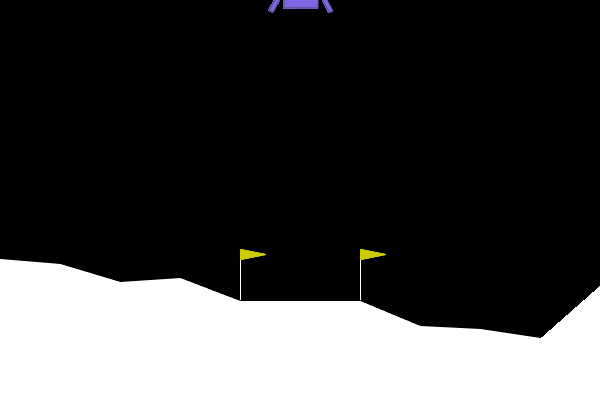

📍 Episode   25 | reward:  -678.5 | steps: 79


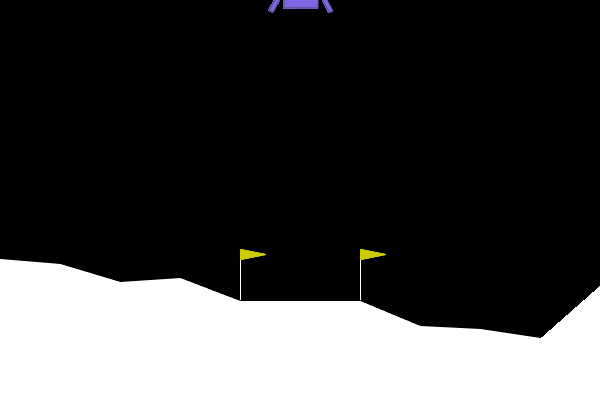

📍 Episode  100 | reward:  -820.5 | steps: 120


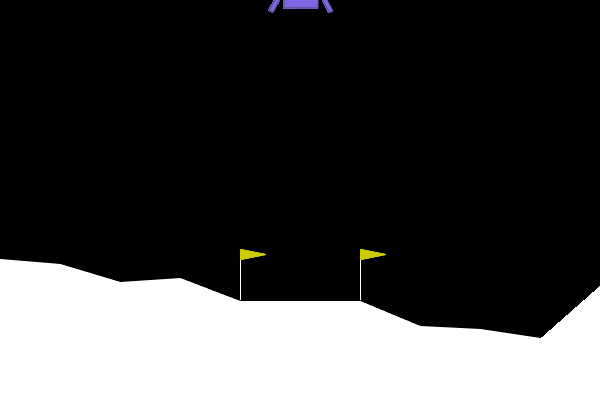

📍 Episode  300 | reward:  -553.9 | steps: 117


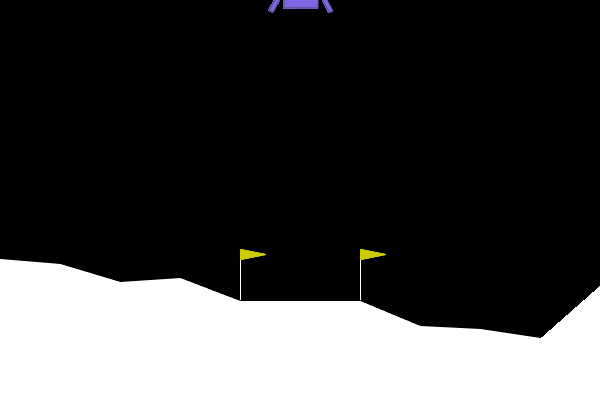

📍 Episode  500 | reward:  -475.8 | steps: 271


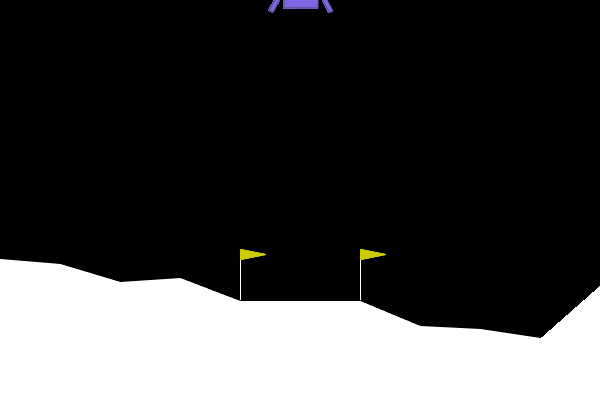

📍 Episode  750 | reward:  -143.9 | steps: 500


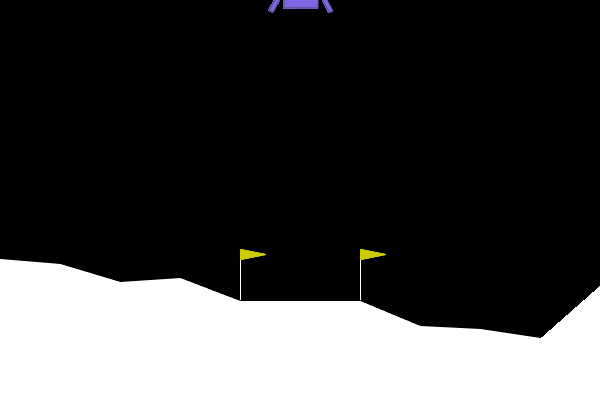

📍 Episode 1000 | reward:    44.0 | steps: 500


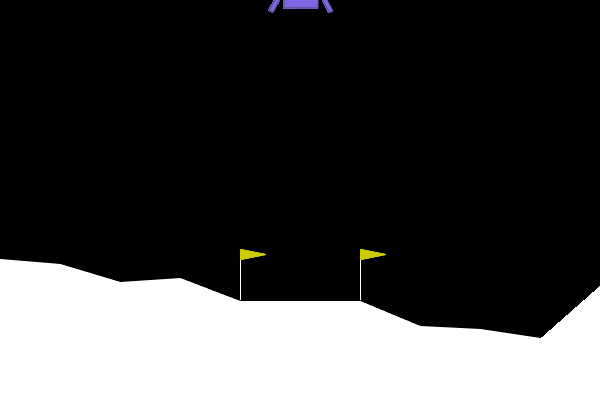

📍 Episode 1500 | reward:   255.5 | steps: 293


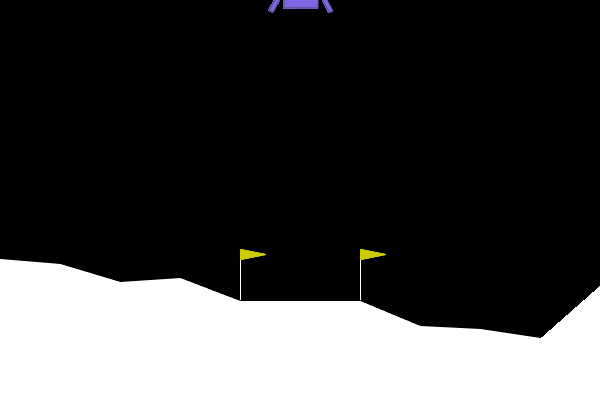

In [24]:
print('🎬 PPO-Eureka checkpoint GIFs\n')
for ck in callback.checkpoint_log:
    ep       = ck['episode']
    reward   = ck['gif_episode_reward']
    steps    = ck['gif_steps']
    gif_path = ck['gif_path']
    print(f'📍 Episode {ep:>4} | reward: {reward:>7.1f} | steps: {steps}')
    if os.path.exists(gif_path):
        ipy_display(Image(filename=gif_path, width=450))
    else:
        print(f'  ⚠️  GIF not found')

## 🏆 Step 13: Final Evaluation

🏆 Final evaluation over 20 episodes (original LunarLander reward)...


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/evaluation.py:71: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(



  Final Mean Reward : 137.84 ± 78.28
  Solved threshold  : 200.0
  Status            : ⚠️  Not yet solved

🎬 Final GIF (reward: 240.9)


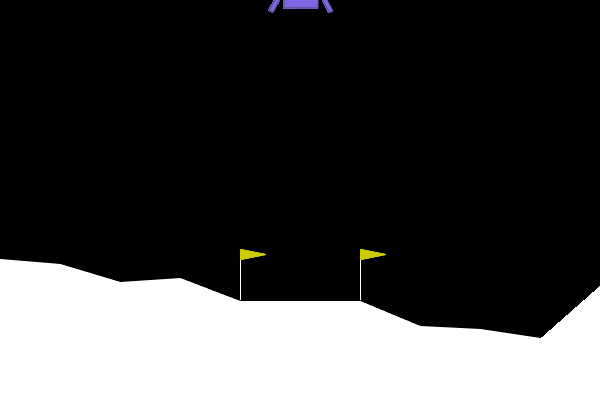

In [25]:
print('🏆 Final evaluation over 20 episodes (original LunarLander reward)...')

eval_env = gym.make(CONFIG['env_id'])
mean_reward, std_reward = evaluate_policy(
    model, eval_env, n_eval_episodes=20, deterministic=True
)
eval_env.close()

print(f'\n  Final Mean Reward : {mean_reward:.2f} ± {std_reward:.2f}')
print(f'  Solved threshold  : 200.0')
status = '✅ SOLVED!' if mean_reward >= 200 else '⚠️  Not yet solved'
print(f'  Status            : {status}')

metrics['final_evaluation'] = {
    'mean_reward': round(mean_reward, 2),
    'std_reward' : round(std_reward, 2),
    'n_episodes' : 20,
    'solved'     : bool(mean_reward >= 200)
}
with open(metrics_path, 'w') as f:
    json.dump(metrics, f, indent=2, cls=NumpyEncoder)

# Final GIF
final_gif_path = os.path.join(GIF_DIR, 'ppo_eureka_final.gif')
final_reward, final_steps = record_gif(
    model=model, reward_fn=best_reward_fn,
    gif_path=final_gif_path, config=CONFIG
)
print(f'\n🎬 Final GIF (reward: {final_reward:.1f})')
ipy_display(Image(filename=final_gif_path, width=450))

## 📦 Step 14: Download Everything

In [26]:
from google.colab import files

zip_path = '/content/ppo_eureka_results'
print('📦 Creating zip archive...')
shutil.make_archive(zip_path, 'zip', '/content', 'ppo_eureka_results')
zip_full = zip_path + '.zip'

size_mb = os.path.getsize(zip_full) / (1024 * 1024)
print(f'   Size: {size_mb:.1f} MB')

print('\n📂 Contents:')
for root, dirs, filenames in os.walk(BASE_DIR):
    level     = root.replace(BASE_DIR, '').count(os.sep)
    indent    = '  ' * level
    subindent = '  ' * (level + 1)
    print(f'{indent}{os.path.basename(root)}/')
    for filename in sorted(filenames):
        fpath = os.path.join(root, filename)
        fsize = os.path.getsize(fpath) / 1024
        print(f'{subindent}{filename}  ({fsize:.0f} KB)')

print('\n⬇️  Downloading...')
files.download(zip_full)

📦 Creating zip archive...
   Size: 2.7 MB

📂 Contents:
ppo_eureka_results/
  reward_functions/
  gifs/
    ppo_eureka_episode_0005.gif  (26 KB)
    ppo_eureka_episode_0025.gif  (122 KB)
    ppo_eureka_episode_0100.gif  (26 KB)
    ppo_eureka_episode_0300.gif  (33 KB)
    ppo_eureka_episode_0500.gif  (57 KB)
    ppo_eureka_episode_0750.gif  (135 KB)
    ppo_eureka_episode_1000.gif  (897 KB)
    ppo_eureka_episode_1500.gif  (466 KB)
    ppo_eureka_final.gif  (437 KB)
  plots/
    ppo_eureka_training_curves.png  (428 KB)
  models/
    ppo_eureka_checkpoint_ep0005.zip  (57 KB)
    ppo_eureka_checkpoint_ep0025.zip  (143 KB)
    ppo_eureka_checkpoint_ep0100.zip  (146 KB)
    ppo_eureka_checkpoint_ep0300.zip  (146 KB)
    ppo_eureka_checkpoint_ep0500.zip  (146 KB)
    ppo_eureka_checkpoint_ep0750.zip  (146 KB)
    ppo_eureka_checkpoint_ep1000.zip  (146 KB)
    ppo_eureka_checkpoint_ep1500.zip  (146 KB)
    ppo_eureka_final.zip  (146 KB)
  metrics/
    ppo_eureka_metrics.json  (322 KB)

⬇️  Do

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## ✅ Done!

`ppo_eureka_results.zip` contains:

```
ppo_eureka_results/
├── gifs/
│   ├── ppo_eureka_episode_0001.gif
│   ├── ppo_eureka_episode_0005.gif
│   ├── ppo_eureka_episode_0010.gif
│   ├── ppo_eureka_episode_0025.gif
│   ├── ppo_eureka_episode_0050.gif
│   ├── ppo_eureka_episode_0100.gif
│   ├── ppo_eureka_episode_0200.gif
│   ├── ppo_eureka_episode_0500.gif
│   └── ppo_eureka_final.gif
├── models/
│   ├── ppo_eureka_checkpoint_ep*.zip  (one per checkpoint)
│   └── ppo_eureka_final.zip
├── metrics/
│   ├── ppo_eureka_metrics.json   ← all episode rewards + eureka loop data
│   └── eureka_iterations.json    ← score per iteration (for frontend chart)
├── reward_functions/
│   ├── iteration_01.py           ← Claude's first attempt
│   ├── iteration_02.py           ← Revised after feedback
│   ├── iteration_03.py           ← Final refinement
│   └── best.py                   ← Whichever scored highest
└── plots/
    ├── ppo_eureka_training_curves.png
    └── eureka_iterations.png
```
